**LABORATORIO 1: NATURALEZA DEL SONIDO Y DIGITALIZACION**

1. Configuración Inicial
Ejecute esta celda primero. Instala las librerías necesarias y configura el entorno de
visualización.

In [ ]:
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interact
# ⚙️ Configuración de gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Entorno listo. Puede continuar con la Parte 1.")



✅ Entorno listo. Puede continuar con la Parte 1.


2. Parte 1: La Señal "Analógica" (Referencia)
El mundo real es continuo. Para visualizarlo en la computadora, simularemos una señal
"analógica" usando una frecuencia de muestreo muy alta (10,000 Hz), que servirá como
nuestra referencia ideal.

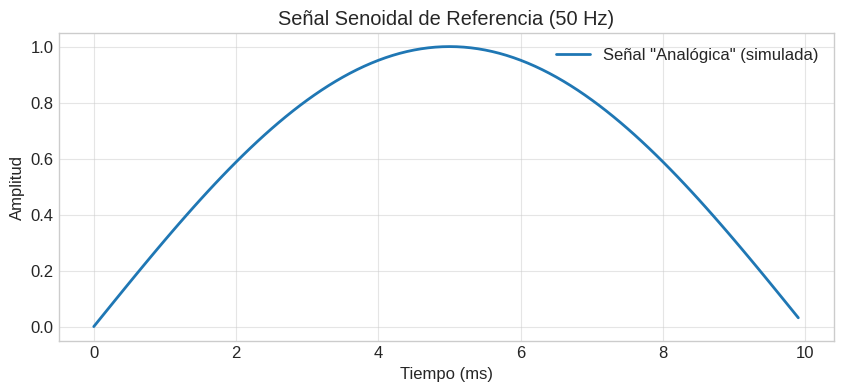

🔊 Reproduciendo señal de referencia...


In [ ]:


# 📝 Parámetros de la señal
frecuencia_original = 50 # Hz (frecuencia de la onda)
duracion = 0.01 # segundos
fs_analogico = 10000 # Hz (muy alto para simular continuidad)
# 📐 Generar eje de tiempo
t = np.linspace(0, duracion, int(fs_analogico * duracion), endpoint=False)
# 🌊 Generar onda senoidal pura (señal analógica simulada)
senal_analogica = np.sin(2 * np.pi * frecuencia_original * t)
# 📊 Visualización
plt.figure(figsize=(10, 4))
plt.plot(t * 1000, senal_analogica, label='Señal "Analógica" (simulada)', linewidth=2)
plt.title('Señal Senoidal de Referencia (50 Hz)')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()
# 🔊 Escuchar (opcional, requiere audio habilitado en el navegador)
print("🔊 Reproduciendo señal de referencia...")
display(Audio(senal_analogica, rate=fs_analogico))


3. Parte 2: Muestreo Interactivo (Sampling)
El muestreo consiste en tomar "fotografías" de la señal a intervalos regulares. Usemos un
control deslizante para ver cómo cambia la representación al variar la frecuencia de
muestreo (fs).

In [ ]:

def visualizar_muestreo(fs_muestreo):
    """Función que muestrea la señal y compara con la referencia"""
    # Generar tiempos de muestreo
    t_muestreo = np.arange(0, duracion, 1/fs_muestreo)
    # Tomar muestras de la señal analógica
    muestras = np.sin(2 * np.pi * frecuencia_original * t_muestreo)
    # Gráfico comparativo
    plt.figure(figsize=(10, 4))
    plt.plot(t * 1000, senal_analogica, 'gray', alpha=0.5, label='Señal original')
    plt.stem(t_muestreo * 1000, muestras, linefmt='b-', markerfmt='bo', basefmt=' ',
             label='Muestras tomadas')
    plt.title(f'Muestreo a {fs_muestreo} Hz')
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    # Explicación pedagógica
    if fs_muestreo < 2 * frecuencia_original:
        print("⚠️ ATENCIÓN: fs < 2×f. Estás por debajo del límite de Nyquist. ¡Aparecerá aliasing!")
    else:
        print("✅ Buen muestreo. La frecuencia de muestreo cumple Nyquist (fs ≥ 2×f).")

# 🎛️ Control interactivo
print("🎛️ Use el deslizador para cambiar la frecuencia de muestreo (50 Hz a 200 Hz)")
interact(visualizar_muestreo, fs_muestreo=widgets.IntSlider(min=50, max=200, step=10,
         value=100, description='fs (Hz):'));

🎛️ Use el deslizador para cambiar la frecuencia de muestreo (50 Hz a 200 Hz)


interactive(children=(IntSlider(value=100, description='fs (Hz):', max=200, min=50, step=10), Output()), _dom_…

4. Parte 3: Cuantización Interactiva (Resolución en Bits)
Una vez muestreada, la amplitud debe convertirse a números enteros. Menos bits =
menos niveles posibles = más "escalones".

In [ ]:
def cuantizar_senal(bits):
    """Aplica cuantización de 'bits' a la señal muestreada y la visualiza"""
    # Muestreamos primero a una tasa segura
    fs_seguro = 1000
    t_seguro = np.arange(0, duracion, 1/fs_seguro)
    senal_muestreada = np.sin(2 * np.pi * frecuencia_original * t_seguro)
    # Fórmula de cuantización simétrica (normalizada entre -1 y 1)
    niveles = 2**bits
    senal_cuantizada = np.round(senal_muestreada * (niveles/2 - 1)) / (niveles/2 - 1)
    # Gráfico
    plt.figure(figsize=(10, 4))
    plt.plot(t_seguro * 1000, senal_muestreada, 'gray', alpha=0.6, label='Señal muestreada (continua)')
    plt.plot(t_seguro * 1000, senal_cuantizada, 'r-', linewidth=2, label=f'Cuantizada ({bits} bits)')
    plt.title(f'Cuantización: {bits} bits → {niveles} niveles posibles')
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud cuantizada')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    # Explicación
    print(f"📊 Con {bits} bits tenemos {niveles} niveles. El 'escalado' visible es el ruido de cuantización.")

# 🎛️ Control interactivo
print("🎛️ Ajuste la profundidad de bits para ver el efecto en la precisión de amplitud")
interact(cuantizar_senal, bits=widgets.IntSlider(min=2, max=8, step=1, value=4,
         description='Bits:'));

🎛️ Ajuste la profundidad de bits para ver el efecto en la precisión de amplitud


interactive(children=(IntSlider(value=4, description='Bits:', max=8, min=2), Output()), _dom_classes=('widget-…

5. Parte 4: Aliasing (Solapamiento Frecuencial)
Demostración visual de qué ocurre cuando violamos el teorema de Nyquist. Una
frecuencia alta "se disfraza" como una baja.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


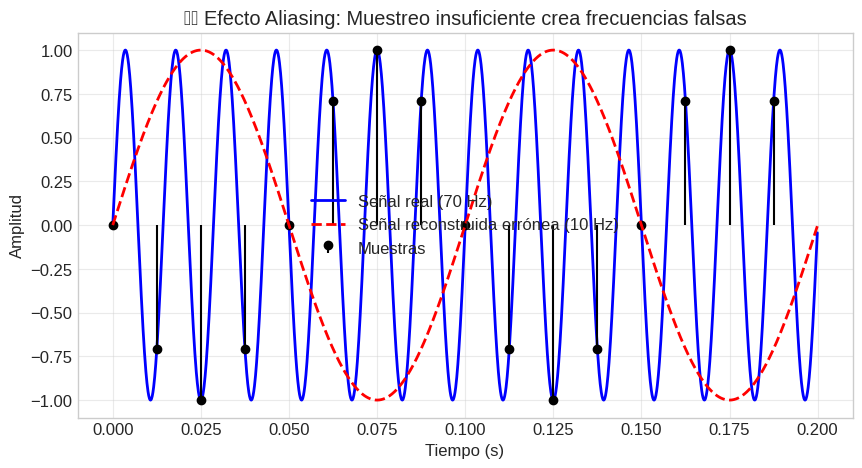

📌 Teorema de Nyquist: fs debe ser ≥ 140 Hz para 70 Hz.
📌 Usamos fs = 80 Hz → ¡INFERIOR AL LÍMITE!
📌 Resultado: El cerebro/computadora interpreta una onda de 10 Hz.


In [ ]:
def demostrar_aliasing():
    """Compara señal original, muestreo insuficiente y reconstrucción errónea"""
    # Frecuencias
    f_alta = 70  # Hz (señal real)
    fs_baja = 80  # Hz (frecuencia de muestreo)
    # Tiempos
    t = np.linspace(0, 0.2, 2000, endpoint=False)
    t_muestreo = np.arange(0, 0.2, 1/fs_baja)
    # Señales
    senal_real = np.sin(2 * np.pi * f_alta * t)
    muestras = np.sin(2 * np.pi * f_alta * t_muestreo)
    # Frecuencia que "percibimos" al reconstruir mal (alias)
    f_alias = abs(f_alta - fs_baja)  # 70 - 80 = 10 Hz (en valor absoluto)
    senal_alias = np.sin(2 * np.pi * f_alias * t)
    # Gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(t, senal_real, 'b', linewidth=2, label=f'Señal real ({f_alta} Hz)')
    plt.stem(t_muestreo, muestras, linefmt='k-', markerfmt='ko', basefmt=' ',
             label='Muestras')
    plt.plot(t, senal_alias, 'r--', linewidth=2, label=f'Señal reconstruida errónea ({f_alias} Hz)')
    plt.title('⚠️ Efecto Aliasing: Muestreo insuficiente crea frecuencias falsas')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    print(f"📌 Teorema de Nyquist: fs debe ser ≥ {2*f_alta} Hz para {f_alta} Hz.")
    print(f"📌 Usamos fs = {fs_baja} Hz → ¡INFERIOR AL LÍMITE!")
    print(f"📌 Resultado: El cerebro/computadora interpreta una onda de {f_alias} Hz.")

demostrar_aliasing()

6. Parte 5: Dominio del Tiempo vs. Dominio de la Frecuencia
La Transformada de Fourier nos permite ver "qué ingredientes (frecuencias)" tiene un
sonido.

/tmp/ipykernel_522/3613650421.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_522/3613650421.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


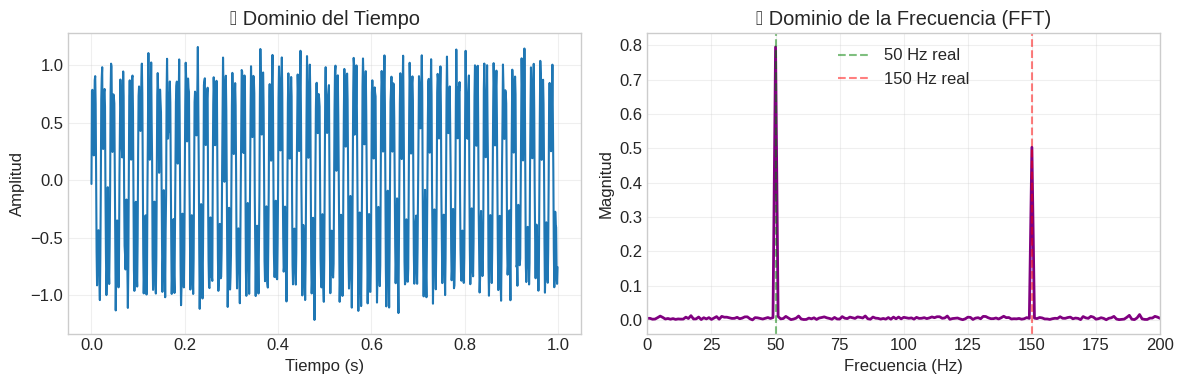

🔍 Observe los picos en 50 Hz y 150 Hz. La FFT descompone la señal en sus 'notas' individuales.


In [ ]:
def analisis_fourier_simple():
    """Genera una señal compuesta y muestra su espectro de frecuencias"""
    fs = 1000
    t = np.linspace(0, 1, fs, endpoint=False)
    # Señal compuesta: 50 Hz + 150 Hz + ruido leve
    senal = (0.8 * np.sin(2 * np.pi * 50 * t) +
             0.5 * np.sin(2 * np.pi * 150 * t) +
             0.1 * np.random.randn(len(t)))
    # 🔄 Transformada Rápida de Fourier (FFT)
    espectro = np.fft.fft(senal)
    frecuencias = np.fft.fftfreq(len(senal), d=1/fs)
    # Tomamos solo la mitad positiva (el espectro es simétrico)
    idx_pos = frecuencias >= 0
    f_pos = frecuencias[idx_pos]
    amp_pos = np.abs(espectro[idx_pos]) * 2 / len(senal)  # Normalización
    # Gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    # Dominio del tiempo
    ax1.plot(t, senal, linewidth=1.5)
    ax1.set_title('📈 Dominio del Tiempo')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud')
    ax1.grid(True, alpha=0.3)
    # Dominio de la frecuencia
    ax2.plot(f_pos, amp_pos, color='purple', linewidth=2)
    ax2.set_title('📊 Dominio de la Frecuencia (FFT)')
    ax2.set_xlabel('Frecuencia (Hz)')
    ax2.set_ylabel('Magnitud')
    ax2.set_xlim(0, 200)
    ax2.grid(True, alpha=0.3)
    ax2.axvline(50, color='g', linestyle='--', alpha=0.5, label='50 Hz real')
    ax2.axvline(150, color='r', linestyle='--', alpha=0.5, label='150 Hz real')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    print("🔍 Observe los picos en 50 Hz y 150 Hz. La FFT descompone la señal en sus 'notas' individuales.")

analisis_fourier_simple()

# Actividades:
Responda las siguientes preguntas en un documento aparte o en el mismo notebook.
Justifique sus respuestas con ejemplos del laboratorio.
1. Muestreo: Si graba un tono puro de 300 Hz, ¿cuál es la frecuencia de muestreo
mínima teórica para evitar aliasing? ¿Por qué en la práctica se usa un valor
mayor?

La frecuencia de muestreo minima es de 600 Hz, se usa un valor mayor por seguridad, ya que ningun filtro anti aliasing corta perfectamente en la frecuencia de Nyquist por lo que al subir la frecuencia de muestreo el filtro tiene margen para una transicion gradual.


2. Cuantización: Un audio de estudio se graba a 24 bits y 48 kHz. Otro archivo
comprimido para web usa 8 bits y 22 kHz. Describa dos diferencias auditivas y
visuales que esperaría encontrar entre ambos.

Un audio de estudio grabado a 24 bits y 48 kHz tendrá notablemente mayor calidad que uno comprimido a 8 bits y 22 kHz. Las diferencias se pueden observar tanto de forma auditiva como visual.

En cuanto a lo auditivo, el archivo de 8 bits solo dispone de 256 niveles de amplitud, mientras que el de 24 bits cuenta con más de 16 millones, por lo que al escuchar el archivo de 8 bits se percibiria un ruido de fondo constante, producto del error de cuantización que se muestra en la parte 3 del laboratorio (cuanto menos bits se usan, más "escalones" hay entre el valor real y el valor asignado), además, al grabar a solo 22 kHz, la frecuencia de Nyquist queda en 11 kHz, por lo que todos los sonidos agudos por encima de ese límite se pierden directamente.

En cuanto a lo visual, si graficamos ambas señales (parte 3 del laboratorio), el archivo de 8 bits mostraría claramente los escalones característicos del ruido de cuantización en la forma de onda, mientras que el de 24 bits seguiría la curva original de manera casi perfecta.



3. Aliasing: En el código de la Parte 4, cambie f_alta = 90 y fs_baja = 80. Ejecute
mentalmente o en código: ¿qué frecuencia "falsa" aparecerá? Explique el cálculo.

En este ejemplo modificamos las frecuencias de la prueba de 70 hz y 80 hz a una señal real de 90 hz y una muestra de 80 hz, agravando aun mas la situacion del primer ejemplo ya que ahora la señal real de 90 Hz supera completamente a la frecuencia de muestreo de 80 Hz, cuando el mínimo necesario según Nyquist sería de 180 Hz. Sin embargo, el alias resultante es el mismo (10 Hz) porque la diferencia numérica entre ambas frecuencias es idéntica en los dos casos.

En el gráfico podemos observar la señal azul oscilando más rápido que en el ejemplo original, pero la línea roja punteada (la señal reconstruida erróneamente) es igual: una onda muy lenta de 10 Hz que no tiene ninguna relación con la señal real de 90 Hz que se quería capturar.

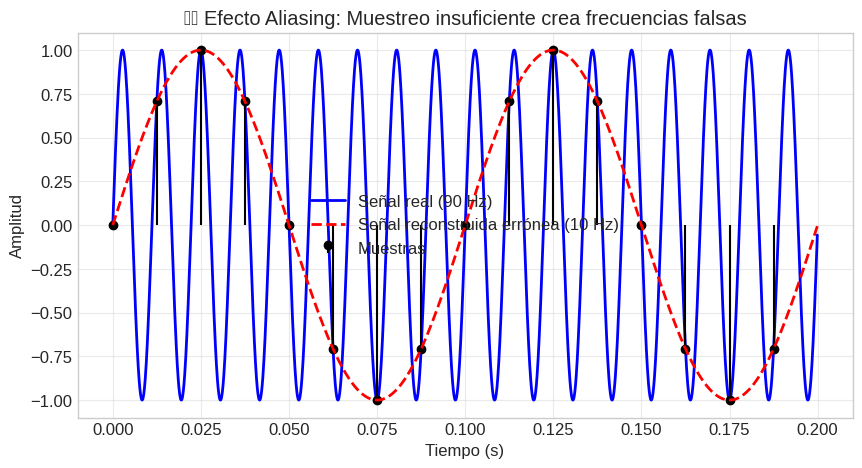

📌 Teorema de Nyquist: fs debe ser ≥ 180 Hz para 90 Hz.
📌 Usamos fs = 80 Hz → ¡INFERIOR AL LÍMITE!
📌 Resultado: El cerebro/computadora interpreta una onda de 10 Hz.


In [ ]:
def demostrar_aliasing():
    """Compara señal original, muestreo insuficiente y reconstrucción errónea"""
    # Frecuencias
    f_alta = 90  # Hz (señal real)
    fs_baja = 80  # Hz (frecuencia de muestreo)
    # Tiempos
    t = np.linspace(0, 0.2, 2000, endpoint=False)
    t_muestreo = np.arange(0, 0.2, 1/fs_baja)
    # Señales
    senal_real = np.sin(2 * np.pi * f_alta * t)
    muestras = np.sin(2 * np.pi * f_alta * t_muestreo)
    # Frecuencia que "percibimos" al reconstruir mal (alias)
    f_alias = abs(f_alta - fs_baja)  # 70 - 80 = 10 Hz (en valor absoluto)
    senal_alias = np.sin(2 * np.pi * f_alias * t)
    # Gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(t, senal_real, 'b', linewidth=2, label=f'Señal real ({f_alta} Hz)')
    plt.stem(t_muestreo, muestras, linefmt='k-', markerfmt='ko', basefmt=' ',
             label='Muestras')
    plt.plot(t, senal_alias, 'r--', linewidth=2, label=f'Señal reconstruida errónea ({f_alias} Hz)')
    plt.title('⚠️ Efecto Aliasing: Muestreo insuficiente crea frecuencias falsas')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    print(f"📌 Teorema de Nyquist: fs debe ser ≥ {2*f_alta} Hz para {f_alta} Hz.")
    print(f"📌 Usamos fs = {fs_baja} Hz → ¡INFERIOR AL LÍMITE!")
    print(f"📌 Resultado: El cerebro/computadora interpreta una onda de {f_alias} Hz.")

demostrar_aliasing()


4. Dominios: Si aplica la FFT a un archivo .wav de voz humana y observa un pico
dominante en 220 Hz, ¿qué información le da esto sobre la señal original? ¿Podría
distinguirse de un silbido de 220 Hz solo con este pico?

Un pico dominante de 220 hz nos diria cual es la frecuencia principal del sonido. No podria distinguirse la voz humana de un silvido solo en base a ese pico, para ver la diferencia se necesitaria analizar el espectro completo.